In [1]:
import torch
import torch.nn as nn 
import torchvision.models as models
import torchvision.transforms as transforms
import pandas as pd
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from PIL import Image, ImageFile
from pytorch_grad_cam import GradCAMPlusPlus

In [2]:
df_info = pd.read_csv("data/datasets_local/DATA_LABELS_TOTAL.csv")

In [3]:
print(df_info.columns.tolist())

['folder_name', 'file_name', '문화재', '문화', '자연', '테마공원', '시장', '거리', '공원', '데이트/로맨틱', '힐링/여유', '럭셔리/고급', '액티브/아웃도어', '가족/키즈', '야경/밤감성']


In [ ]:

LABELS_P1 = df_info.columns[2:9].tolist()
LABELS_P2 = df_info.columns[9:14].tolist()
print(LABELS_P1,LABELS_P2)

['문화재', '문화', '자연', '테마공원', '시장', '거리', '공원', '데이트/로맨틱'] ['힐링/여유', '럭셔리/고급', '액티브/아웃도어', '가족/키즈', '야경/밤감성']


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 레이블 정의
# LABELS_P1 = ['문화유산', '문화', '자연', '전시관', '테마공원', '시장', '거리', '공원'] # 8개
# LABELS_P2 = ['데이트/로맨틱', '힐링/여유', '럭셔리/고급','액티브/아웃도어','가족/키즈','야경/밤감성'] # 6개
#TARGET_COLUMNS = LABELS_P1 + LABELS_P2 
TARGET_COLUMNS = LABELS_P1 + LABELS_P2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_DIR = "data/datasets_local/images"

## GradCAM 클래스 정의

In [6]:
# GradCAM 클래스 정의
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activations)
        self.target_layer.register_full_backward_hook(self.save_gradients)

    def save_activations(self, module, input, output): self.activations = output
    def save_gradients(self, module, grad_input, grad_output): self.gradients = grad_output[0]

    def generate(self, input_tensor, class_idx):
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze().detach().cpu().numpy()
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224, 224))
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

In [7]:
# 모델 로드 및 특징 추출기 설정
def load_model(path, num_classes):
    model = models.efficientnet_b0(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    
    model.to(DEVICE).eval()
    return model

## 장소추천 TOP 3

In [8]:
def get_top3_similar_metadata(prob1, prob2, df_info):
    # 모델 결과를 0.5 기준으로 이진화 (1 또는 0)
    # P1 (장소 8종), P2 (분위기 6종) 순서대로 결합
    pred_probs = np.concatenate([prob1, prob2])
    pred_binary = (pred_probs >= 0.5).astype(int)
       
    # CSV 데이터와 모델 예측값 사이의 일치 점수 계산 (Hamming Distance 유사 개념)
    # 각 행(Row)에 대해 모델이 1로 예측한 곳에 1이 있는지 점수.
    df_scores = df_info.copy()
    
    # 각 행의 벡터와 예측 벡터 간의 일치 개수 계산
    csv_vectors = df_info[TARGET_COLUMNS].values

    # (예측이 1인 곳과 실제가 1인 곳의 합 + 예측이 0인 곳과 실제가 0인 곳의 합)
    match_counts = np.sum(csv_vectors == pred_binary, axis=1)
    df_scores['match_score'] = match_counts
    df_sorted = df_scores.sort_values(by='match_score', ascending=False)

    top3_unique_matches = df_sorted.drop_duplicates(subset=['folder_name'], keep='first')

    #df_scores['match_score'] = match_counts
    
    # 일치 점수가 높은 순으로 TOP 3 추출
    # 점수가 같다면 랜덤하게 섞거나 상위 항목을 가져옵니다.
    top3_matches = top3_unique_matches.head(3) # df_scores.sort_values(by='match_score', ascending=False).head(3)
    
    return top3_matches, pred_binary

## Grad Cam show

In [9]:
def show_dual_gradcam(img_path, mask1, mask2, label1, prob1, label2, prob2):
    # 1. 원본 이미지 로드 및 전처리
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    def overlay_heatmap(img, mask):
        heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        return cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    # 2. 히트맵 합성
    res1 = overlay_heatmap(img, mask1)
    res2 = overlay_heatmap(img, mask2)

    # 3. 시각화 (Matplotlib 활용)
    plt.figure(figsize=(18, 6))

    # (1) 원본 이미지
    plt.subplot(1, 3, 1)
    plt.title(f"Original: {os.path.basename(img_path)}")
    plt.imshow(img)
    plt.axis('off')

    # (2) Part 1 장소 결과
    plt.subplot(1, 3, 2)
    plt.title(f"P1 [Place]: {label1} ({prob1*100:.1f}%)")
    plt.imshow(res1)
    plt.axis('off')

    # (3) Part 2 분위기 결과
    plt.subplot(1, 3, 3)
    plt.title(f"P2 [Mood]: {label2} ({prob2*100:.1f}%)")
    plt.imshow(res2)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## 모델 추론

In [ ]:
def run_inference_with_cam(img_path, model1, model2):
    # 1. 이미지 전처리
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    raw_img = Image.open(img_path).convert('RGB')
    input_tensor = transform(raw_img).unsqueeze(0).to(DEVICE)

    # 2. 모델 추론
    with torch.no_grad():
        out1 = model1(input_tensor)
        out2 = model2(input_tensor)
        prob1 = torch.sigmoid(out1).cpu().numpy()[0]
        prob2 = torch.sigmoid(out2).cpu().numpy()[0]

    # 3. 결과 출력
    print(f"\n--- [ 분석 결과: {img_path} ] ---")
    top1_idx = np.argmax(prob1)
    top2_idx = np.argmax(prob2)

    # 모델 예측 값 (카테고리명)
    p1_label = LABELS_P1[top1_idx]
    p2_label = LABELS_P2[top2_idx]

    print(f"장소(P1): {p1_label} ({prob1[top1_idx]*100:.2f}%)")
    print(f"분위기(P2): {p2_label} ({prob2[top2_idx]*100:.2f}%)")

 
    top3_df, binary_result = get_top3_similar_metadata(prob1, prob2, df_info)

    print(f"모델 예측 이진화 결과: {binary_result}")
    print(f"--- [ 모델 결과와 가장 유사한 학습 데이터 TOP 3 ] ---")

    for i, (idx, row) in enumerate(top3_df.iterrows()):
        print(f"{i+1}위: {row['folder_name']}")
        print(f"파일명: {row['file_name']}")
        print(f"일치 지표 수: {row['match_score']} / {len(binary_result)}")
        print("-" * 30)
        img_tmp = Image.open(f"{IMG_DIR}/{row['file_name']}")
        # 페이지에 띄우기
        #plt.figure(figsize=(10, 6)) # 이미지 출력 크기 설정
        plt.imshow(img_tmp)
        plt.axis('off') # 축(axis) 숨기기
        plt.show()

    # 1. Grad-CAM 엔진 초기화 (EfficientNet-B0의 마지막 Conv 레이어 타겟)
    target_layer1 = model1.features[len(LABELS_P1)]
    target_layer2 = model2.features[len(LABELS_P2)]
    
    cam1 = GradCAM(model1, target_layer1)
    cam2 = GradCAM(model2, target_layer2)

    # 2. 각 모델별 최고 확률 인덱스 추출
    idx1 = np.argmax(prob1)
    idx2 = np.argmax(prob2)

    # 3. 히트맵 마스크 생성
    mask1 = cam1.generate(input_tensor, idx1)
    mask2 = cam2.generate(input_tensor, idx2)

    # 4. 시각화 호출
    show_dual_gradcam(
        img_path, 
        mask1, mask2, 
        LABELS_P1[idx1], prob1[idx1], 
        LABELS_P2[idx2], prob2[idx2]
    )

# 샘플이미지 테스트


--- [ 분석 결과: data/datasets_local/sample.jpg ] ---
장소(P1): 거리 (99.99%)
분위기(P2): 가족/키즈 (63.85%)
모델 예측 이진화 결과: [0 0 0 0 0 0 1 0 0 0 0 0 1 0]
--- [ 모델 결과와 가장 유사한 학습 데이터 TOP 3 ] ---
1위: 자생식물학습장
파일명: 자생식물학습장_img_050.jpg
일치 지표 수: 14 / 14
------------------------------


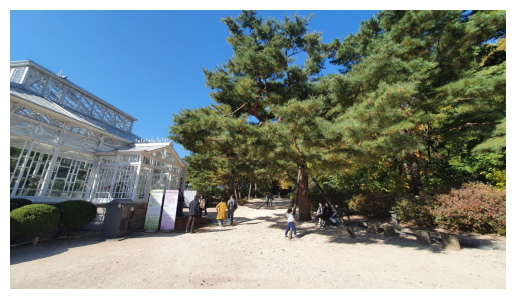

2위: 서대문독립공원_서재필동상
파일명: 서대문독립공원_서재필동상_img_050.jpg
일치 지표 수: 14 / 14
------------------------------


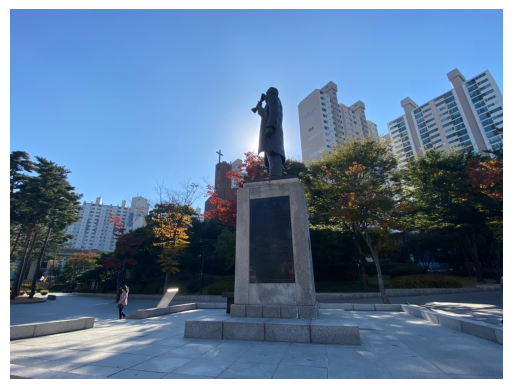

3위: 서대문독립공원_독립관
파일명: 서대문독립공원_독립관_img_050.jpg
일치 지표 수: 14 / 14
------------------------------


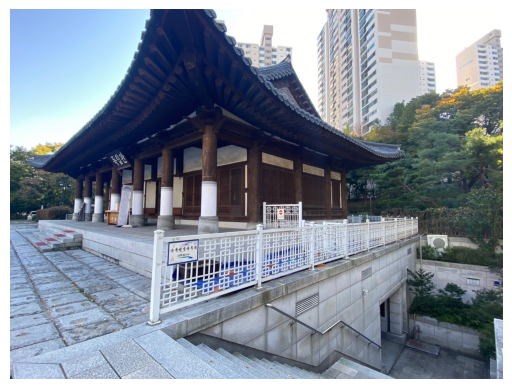

C:\Users\user\AppData\Local\Temp\ipykernel_36292\1137549432.py:37: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36292\1137549432.py:37: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36292\1137549432.py:37: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36292\1137549432.py:37: UserWarning: Glyph 51313 (\N{HANGUL SYLLABLE JOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36292\1137549432.py:37: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_36292\1137549432.py:37: UserWarning: Glyph 51592 (\N{HANGUL SYLLABLE JEU}) missing from font(s)

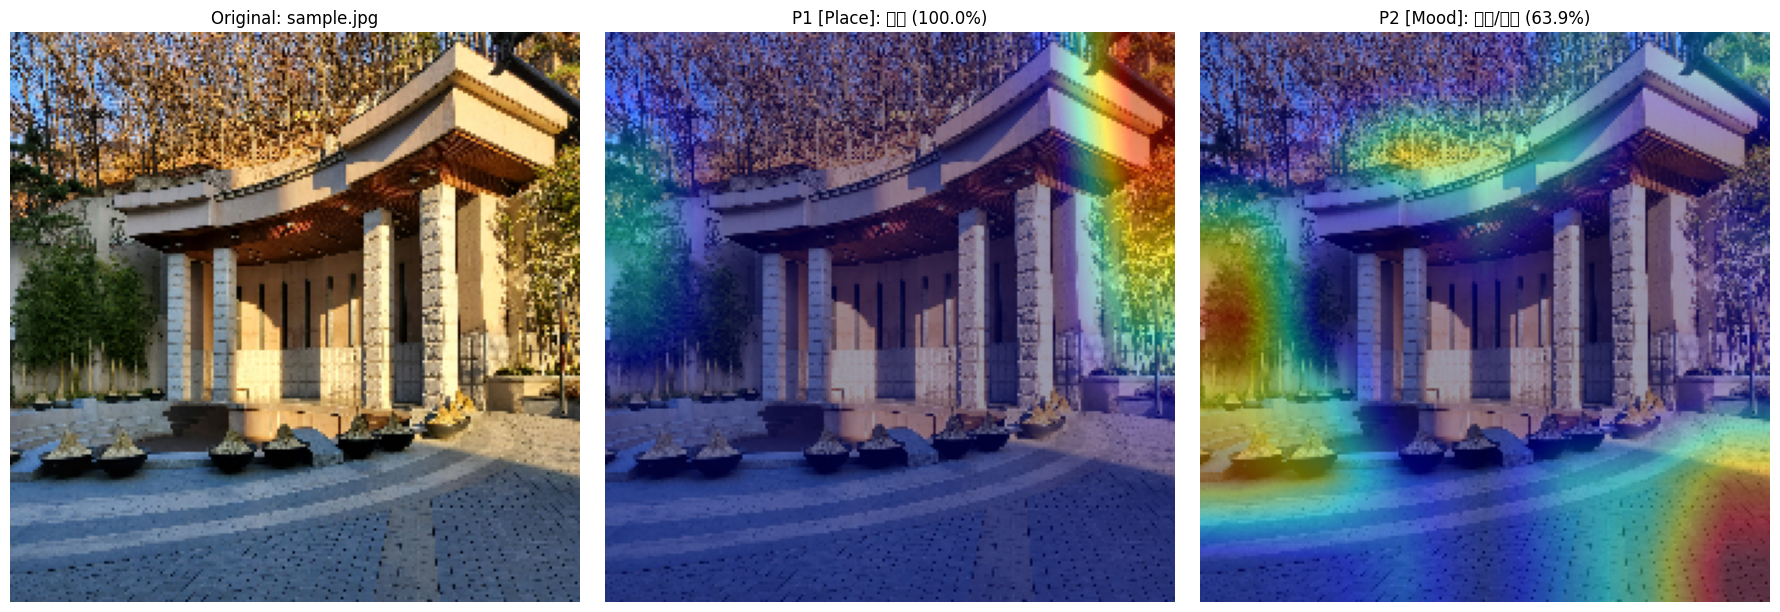

In [ ]:
m1 = load_model("optuna_best_model_efficientnet_part1.pth", num_classes=len(LABELS_P1))
m2 = load_model("optuna_best_model_efficientnet_part2.pth", num_classes=len(LABELS_P2))
    
TEST_IMAGE = "data/datasets_local/sample.jpg" # 실제 파일 경로로 수정
run_inference_with_cam(TEST_IMAGE, m1, m2)